In [1]:
using LinearAlgebra, SparseArrays, Parameters, LinearMaps, Plots

In [2]:
# #1D Matrix operator utility functions.
# spI(n) = spdiagm(n,n, 0 => ones(n))
# ∂1d(n,dx) = spdiagm(n,n+1,0 => -ones(n), 1 => ones(n))/dx
# c(n) = spdiagm(n,n+1,0 => ones(n), 1 => ones(n))/2
# χ(n) = spdiagm(n,n+2, 1 => ones(n))


In [3]:
# A = spI(5)
# rank(∂1d(5,0.1))
# ∂1d(5,0.1)

In [4]:
using LinearAlgebra, Serialization

# Define parameters
Base.@kwdef struct Params
    y_BC::String = "Neumann" # or "traction_free"
    k::Float64 = 1e-8       # small numerical factor
    λ::Float64 = 1.0
    μ::Float64 = 1.0
    Lx::Float64 = 1.0
    Nx::Int = 15
    Δx::Float64 = Lx/(Nx-1) # spatial step
    Ly::Float64 = 1.0
    Ny::Int = 16
    Δy::Float64 = Ly/(Ny-1) # spatial step
    T::Int = 10 + 1         # number of steps for pseudotime
    dt::Float64 = 1/(T-1)   # step in pseudotime
    tol::Float64 = 1e-6     # convergence tolerance
    max_iter::Int = 20      # max staggered iterations
    savefile::String = "sol.jls" # file to save iterations
end

# ------------------------------------------------------------
# Grid indexing (column major)
# ------------------------------------------------------------
lin(i,j,Nx) = i + (j-1)*Nx

# ------------------------------------------------------------
# Derivatives (1st order boundary, 2nd interior)
# ------------------------------------------------------------
function Dx(f,i,j,p::Params)
    Nx = p.Nx
    Δx = p.Δx
    if i == 1
        return (f[i+1,j] - f[i,j]) / Δx
    elseif i == Nx
        return (f[i,j] - f[i-1,j]) / Δx
    else
        return (f[i+1,j] - f[i-1,j]) / (2Δx)
    end
end

function Dy(f,i,j,p::Params)
    Ny = p.Ny
    Δy = p.Δy
    if j == 1
        return (f[i,j+1] - f[i,j]) / Δy
    elseif j == Ny
        return (f[i,j] - f[i,j-1]) / Δy
    else
        return (f[i,j+1] - f[i,j-1]) / (2Δy)
    end
end

# degradation function
function g(d,i,j,p::Params)
    return (1.0-d[i,j])^2 + p.k
end

# Build Q,P coefficients after linearization
function build_QP(d,a1_bar,a2_bar,p::Params)

    Nx = p.Nx
    Ny = p.Ny

    Q11 = zeros(Nx,Ny)
    P11 = zeros(Nx,Ny)
    Q12 = zeros(Nx,Ny)
    P12 = zeros(Nx,Ny)

    Q21 = zeros(Nx,Ny)
    P21 = zeros(Nx,Ny)
    Q22 = zeros(Nx,Ny)
    P22 = zeros(Nx,Ny)

    for j in 1:Ny
        for i in 1:Nx

            a1barx  = Dx(a1_bar,i,j,p)
            a1bary  = Dy(a1_bar,i,j,p)
            a2barx  = Dx(a2_bar,i,j,p)
            a2bary  = Dy(a2_bar,i,j,p)

            λ,μ = p.λ,p.μ

            # pressure
            pres = -(λ + 2μ/3)*(a1barx + a2bary)
            # mask
            if pres <= 0 
                m_p = 1.0
            else    
                m_p = g(d, i, j, p)
            end

            # from linearisation
            fbar = sqrt((a1barx - a2bary)^2 + (a1bary + a2barx)^2)

            if fbar == 0.0 # strictly
                r1x = 1/6 - 1/(2^(3/2))
                r1y = -1/(2^(3/2))
                r2x = -1/(2^(3/2))
                r2y = 1/6 + 1/(2^(3/2))
            else
                r1x = 1/6 - (a1barx - a2bary)/(2fbar)
                r1y = -(a1bary + a2barx)/(2fbar)
                r2x = -(a1bary + a2barx)/(2fbar)
                r2y = 1/6 + (a1barx - a2bary)/(2fbar)
            end

            q1 = (a1barx + a2bary)/6 - 0.5*fbar
            q2 = (a1barx + a2bary)/6 + 0.5*fbar
            # masks
            m_q1 = q1 <= 0 ? 1.0 : g(d, i, j, p)
            m_q2 = q2 <= 0 ? 1.0 : g(d, i, j, p)

            # coefficients
            Q11[i,j] = m_p*(λ + 2μ/3) + m_q1*r1x
            P11[i,j] = 2*m_q1*r1y
            Q12[i,j] = 2*m_q1*r2x
            P12[i,j] = m_p*(λ + 2μ/3) + m_q1*r2y

            Q21[i,j] = m_p*(λ + 2μ/3) + m_q2*r2y
            P21[i,j] = -2*m_q2*r1y
            Q22[i,j] = -2*m_q2*r2x
            P22[i,j] = m_p*(λ + 2μ/3) + m_q2*r1x
        end
    end

    return Q11,P11,Q12,P12,Q21,P21,Q22,P22
end

# Build global matrix M and rhs b
function build_system(Q11,P11,Q12,P12,
                      Q21,P21,Q22,P22,
                      p::Params,
                      a1_left, a2_left,
                      a1_right, a2_right)

    Nx,Ny = p.Nx,p.Ny
    Δx,Δy = p.Δx,p.Δy
    Ntot = Nx*Ny # a1, a2 are vectorized
    Ndof = 2*Ntot # for both a1 and a2

    M = zeros(Ndof,Ndof)
    b = zeros(Ndof)

    # Dirichlet in x
    # for i = 1
    for j in 1:Ny
        k = lin(1,j,Nx)
        k1 = k # for a1 positions in vector [a1, a2]
        k2 = k + Ntot # for a2...
        M[k1,k1]=1; b[k1]=a1_left[j] # grid function of y
        M[k2,k2]=1; b[k2]=a2_left[j]
    end
    # for i = Nx
    for j in 1:Ny
        k = lin(Nx,j,Nx)
        k1 = k # for a1
        k2 = k + Ntot # for a2
        M[k1,k1]=1; b[k1]=a1_right[j] # grid function of y
        M[k2,k2]=1; b[k2]=a2_right[j]
    end
    
    # BC in y
    if p.y_BC=="Neumann" # using 1st order stencils
        # for j=1
        for i in 2:Nx-1 # the edges of x are given by the Dirichlet BCs in x
            k = lin(i,1,Nx)
            k1 = k # for a1 positions in vector [a1, a2]
            k2 = k + Ntot # for a2...
            M[k1,k1] = -1/Δy
            M[k1,lin(i,2,Nx)] = 1/Δy
            M[k2,k2] = -1/Δy
            M[k2,lin(i,2,Nx)+Ntot] = 1/Δy
        end
        # for j=Ny
        for i in 2:Nx-1 # the edges of x are given by the Dirichlet BCs in x
            k = lin(i,Ny,Nx)
            k1 = k # for a1 positions in vector [a1, a2]
            k2 = k + Ntot # for a2...
            M[k1,k1] = 1/Δy
            M[k1,lin(i,Ny-1,Nx)] = -1/Δy
            M[k2,k2] = 1/Δy
            M[k2,lin(i,Ny-1,Nx)+Ntot] = -1/Δy
        end
    elseif p.y_BC=="traction_free"
        #TODO
    end
    
    for j in 2:Ny-1
        for i in 2:Nx-1

            # midpoints in x
            P11_i_mhalf_j = 0.5*(P11[i-1,j]+P11[i,j])
            P11_i_phalf_j = 0.5*(P11[i,j]+P11[i+1,j])
            Q11_i_mhalf_j = 0.5*(Q11[i-1,j]+Q11[i,j])
            Q11_i_phalf_j = 0.5*(Q11[i,j]+Q11[i+1,j])
            P12_i_mhalf_j = 0.5*(P11[i-1,j]+P12[i,j])
            P12_i_phalf_j = 0.5*(P11[i,j]+P12[i+1,j])
            Q12_i_mhalf_j = 0.5*(Q11[i-1,j]+Q12[i,j])
            Q12_i_phalf_j = 0.5*(Q11[i,j]+Q12[i+1,j])
            # midpoints in y
            P21_i_j_mhalf = 0.5*(P21[i,j-1]+P21[i,j])
            P21_i_j_phalf = 0.5*(P21[i,j]+P21[i,j+1])
            Q21_i_j_mhalf = 0.5*(Q21[i,j-1]+Q21[i,j])
            Q21_i_j_phalf = 0.5*(Q21[i,j]+Q21[i,j+1])
            P22_i_j_mhalf = 0.5*(P21[i,j-1]+P22[i,j])
            P22_i_j_phalf = 0.5*(P21[i,j]+P22[i,j+1])
            Q22_i_j_mhalf = 0.5*(Q21[i,j-1]+Q22[i,j])
            Q22_i_j_phalf = 0.5*(Q21[i,j]+Q22[i,j+1])

            k = lin(i,j,Nx)
            k1 = k # for a1
            k2 = k + Ntot # for a2

            # 1st eq; rhs = 0
            # for a1 part
            M[k1,lin(i-1,j-1,Nx)] = 0.25*P11_i_mhalf_j/Δy
            M[k1,lin(i-1,j,Nx)] = Q11_i_mhalf_j/Δx
            M[k1,lin(i-1,j+1,Nx)] = -0.25*P11_i_mhalf_j/Δy
            M[k1,lin(i,j-1,Nx)] = 0.25*(P11_i_mhalf_j-P11_i_phalf_j)/Δy
            M[k1,k1] = -(Q11_i_mhalf_j+Q11_i_phalf_j)/Δx
            M[k1,lin(i,j+1,Nx)] = 0.25*(P11_i_phalf_j-P11_i_mhalf_j)/Δy
            M[k1,lin(i+1,j-1,Nx)] = -0.25*P11_i_phalf_j/Δy
            M[k1,lin(i+1,j,Nx)] = Q11_i_phalf_j/Δx
            M[k1,lin(i+1,j+1,Nx)] = 0.25*P11_i_phalf_j/Δy
            # for a2 part
            M[k1,lin(i-1,j-1,Nx)+Ntot] = 0.25*P12_i_mhalf_j/Δy
            M[k1,lin(i-1,j,Nx)+Ntot] = Q12_i_mhalf_j/Δx
            M[k1,lin(i-1,j+1,Nx)+Ntot] = -0.25*P12_i_mhalf_j/Δy
            M[k1,lin(i,j-1,Nx)+Ntot] = 0.25*(P12_i_mhalf_j-P12_i_phalf_j)/Δy
            M[k1,k2] = -(Q12_i_mhalf_j+Q12_i_phalf_j)/Δx
            M[k1,lin(i,j+1,Nx)+Ntot] = 0.25*(P12_i_phalf_j-P12_i_mhalf_j)/Δy
            M[k1,lin(i+1,j-1,Nx)+Ntot] = -0.25*P12_i_phalf_j/Δy
            M[k1,lin(i+1,j,Nx)+Ntot] = Q12_i_phalf_j/Δx
            M[k1,lin(i+1,j+1,Nx)+Ntot] = 0.25*P12_i_phalf_j/Δy

            # 2nd eq; rhs = 0
            # for a1 part
            M[k2,lin(i-1,j-1,Nx)] = 0.25*Q21_i_j_mhalf/Δx
            M[k2,lin(i-1,j,Nx)] = 0.25*(Q21_i_j_mhalf-Q21_i_j_phalf)/Δx
            M[k2,lin(i-1,j+1,Nx)] = -0.25*Q21_i_j_phalf/Δx
            M[k2,lin(i,j-1,Nx)] = P21_i_j_mhalf/Δy
            M[k2,k1] = -(P21_i_j_mhalf+P21_i_j_phalf)/Δy
            M[k2,lin(i,j+1,Nx)] = P21_i_j_phalf/Δy
            M[k2,lin(i+1,j-1,Nx)] = -0.25*Q21_i_j_mhalf/Δx
            M[k2,lin(i+1,j,Nx)] = 0.25*(Q21_i_j_phalf-Q21_i_j_mhalf)/Δx
            M[k2,lin(i+1,j+1,Nx)] = 0.25*Q21_i_j_phalf/Δx
            # for a2 part
            M[k2,lin(i-1,j-1,Nx)+Ntot] = 0.25*Q22_i_j_mhalf/Δx
            M[k2,lin(i-1,j,Nx)+Ntot] = 0.25*(Q22_i_j_mhalf-Q22_i_j_phalf)/Δx
            M[k2,lin(i-1,j+1,Nx)+Ntot] = -0.25*Q22_i_j_phalf/Δx
            M[k2,lin(i,j-1,Nx)+Ntot] = P22_i_j_mhalf/Δy
            M[k2,k2] = -(P22_i_j_mhalf+P22_i_j_phalf)/Δy
            M[k2,lin(i,j+1,Nx)+Ntot] = P22_i_j_phalf/Δy
            M[k2,lin(i+1,j-1,Nx)+Ntot] = -0.25*Q22_i_j_mhalf/Δx
            M[k2,lin(i+1,j,Nx)+Ntot] = 0.25*(Q22_i_j_phalf-Q22_i_j_mhalf)/Δx
            M[k2,lin(i+1,j+1,Nx)+Ntot] = 0.25*Q22_i_j_phalf/Δx

        end
    end

    return M,b
end

build_system (generic function with 1 method)

In [5]:
p = Params(
    λ = 1.0,
    μ = 1.0,
    Nx = 100,
    Ny = 100,
    max_iter = 1
)

Params("Neumann", 1.0e-8, 1.0, 1.0, 1.0, 100, 0.010101010101010102, 1.0, 100, 0.010101010101010102, 11, 0.1, 1.0e-6, 1, "sol.jls")

In [6]:
a1 = zeros(p.Nx, p.Ny)
a2 = zeros(p.Nx, p.Ny)

a1_bar = copy(a1)
a2_bar = copy(a2)
d = copy(a2)

100×100 Matrix{Float64}:
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0

In [7]:
x = range(0,p.Lx,p.Nx)
y = range(0,p.Ly,p.Ny)
for j in 1:p.Ny
    for i in 1:p.Nx
        a1_bar[i,j] = 1e-4*sin(x[i])*cos(y[j])
        a2_bar[i,j] = 2*1e-3*cos(x[i])*sin(2*y[j])
    end
end

In [8]:
Q11,P11,Q12,P12,Q21,P21,Q22,P22 =
    build_QP(d,a1_bar,a2_bar,p)

([2.333333333333333 2.3333333326486265 … 1.3333412798183204 1.3333408064759258; 2.3333333333329054 2.3333333304557002 … 1.333368024099645 1.3333659897068353; … ; 2.3333333236030014 2.3332679020562637 … 1.58802920298977 1.582374892252678; 2.3333333231588327 2.3332653480177425 … 1.5915118837830993 1.585888390855599], [-0.0 5.233379242704939e-5 … 0.0056319642891558466 0.005461289344839444; 1.308206177593869e-6 0.00010728714418582202 … 0.011776739336861505 0.011426047695504106; … ; 0.00019728488883201278 0.01617739111445327 … 0.87138022805107 0.8649158398019675; 0.0002017374559106299 0.01649008108985102 … 0.8752653962695166 0.8689556771067806], [-0.0 5.233379242704939e-5 … 0.0056319642891558466 0.005461289344839444; 1.308206177593869e-6 0.00010728714418582202 … 0.011776739336861505 0.011426047695504106; … ; 0.00019728488883201278 0.01617739111445327 … 0.87138022805107 0.8649158398019675; 0.0002017374559106299 0.01649008108985102 … 0.8752653962695166 0.8689556771067806], [1.333333333333333 

In [9]:
a1_left  = 0.0*ones(p.Ny)
a1_right = 1e-4*ones(p.Ny)
a2_left  = 0.0*ones(p.Ny)
a2_right = 2*1e-4*ones(p.Ny)

100-element Vector{Float64}:
 0.0002
 0.0002
 0.0002
 0.0002
 0.0002
 0.0002
 0.0002
 0.0002
 0.0002
 0.0002
 0.0002
 0.0002
 0.0002
 ⋮
 0.0002
 0.0002
 0.0002
 0.0002
 0.0002
 0.0002
 0.0002
 0.0002
 0.0002
 0.0002
 0.0002
 0.0002

In [10]:
M,b = build_system(
    Q11,P11,Q12,P12,
    Q21,P21,Q22,P22,
    p,
    a1_left,a1_right,
    a2_left,a2_right)

([1.0 0.0 … 0.0 0.0; 0.0 -98.99999999999999 … 0.0 0.0; … ; 0.0 0.0 … 98.99999999999999 0.0; 0.0 0.0 … 0.0 1.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0002])

In [ ]:
println("rank(M) = ", rank(M))
println("size(M) = ", size(M))
#println("det(M) = ", det(M))
# println("cond(M) = ", cond(M))

In [ ]:
sol = M \ b

1300-element Vector{Float64}:
  1.3619075330126657e-16
  0.0014079344974249777
  0.0005620969285414937
  0.001387075213364819
  0.0006593687841495117
  0.0013044056522548545
  0.0006199924013266236
  0.0012010237743040513
  0.0005482839837170494
  0.001091509524730075
  0.0004419197021206729
  0.0009527546730997597
  0.0003054250476455816
  ⋮
 -0.0009771813693341778
  9.494902673829177e-5
 -0.0008927343063549638
  0.0001005186933966085
 -0.0008829846121656996
  6.121529012762627e-5
 -0.0008862599905304567
  5.9107386983906964e-5
 -0.0008515333143009514
  0.00010809964931119205
 -0.0007811555650214752
  0.0002

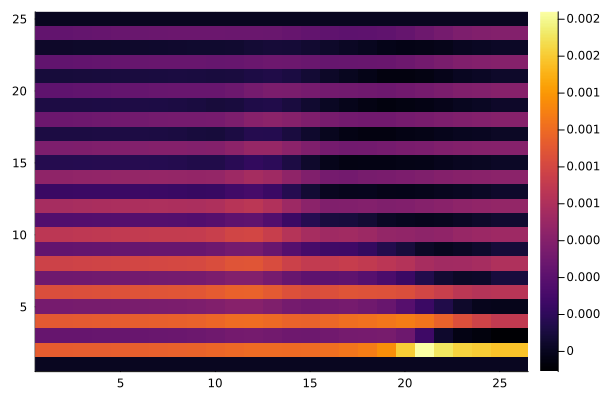

In [ ]:
Ntot = p.Nx*p.Ny
a1sol = reshape(sol[1:Ntot], p.Nx, p.Ny)
heatmap(a1sol)

In [ ]:
a1sol

25×26 Matrix{Float64}:
  1.36191e-16  -1.29947e-16  -1.25338e-16  …   4.63668e-18  -1.33753e-17
  0.00140793    0.00140793    0.00141069       0.00196477    0.00196477
  0.000562097   0.000562097   0.000564807     -0.000136912  -0.000136912
  0.00138708    0.00138708    0.00139294       0.00111798    0.00111798
  0.000659369   0.000659369   0.000664006     -2.5666e-5    -2.5666e-5
  0.00130441    0.00130441    0.00131247   …   0.0010658     0.0010658
  0.000619992   0.000619992   0.000625747      0.000115669   0.000115669
  0.00120102    0.00120102    0.00121068       0.00100348    0.00100348
  0.000548284   0.000548284   0.000554534      0.000101028   0.000101028
  0.00109151    0.00109151    0.001102         0.000899129   0.000899129
  0.00044192    0.00044192    0.000447599  …   6.40997e-5    6.40997e-5
  0.000952755   0.000952755   0.000963031      0.000834145   0.000834145
  0.000305425   0.000305425   0.000309649      4.28784e-5    4.28784e-5
  0.000811812   0.000811812   0.00082

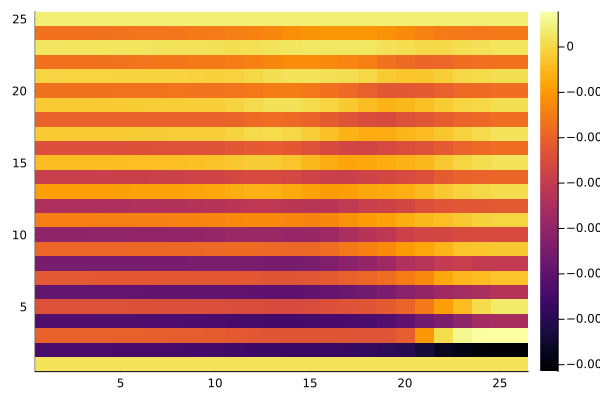

In [ ]:
a2sol = reshape(sol[Ntot+1:2*Ntot], p.Nx, p.Ny)
heatmap(a2sol)

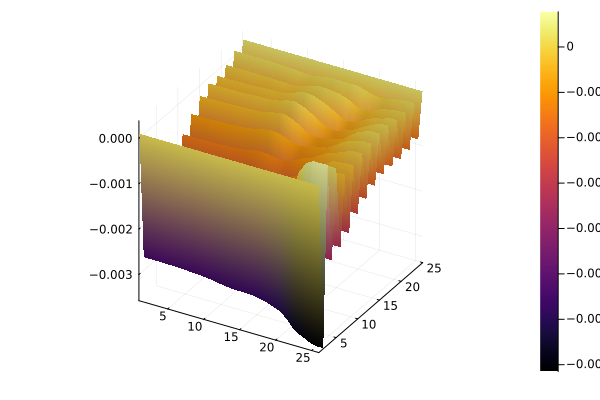

In [ ]:
surface(a2sol)